# **K-Nearest Neighbors**

In this exercise, you will build a classifier using the K-Nearest Neighbors algorithm.

---

### **1. Generating data**

You will start by generating synthetic data for this problem.  

- Generate a dataset with **n = 50 points** in a unit square. Each point should have an assigned label: orange or blue.  
  - Think about the rules to assign the labels (hint: you need a boundary rule to classify points as orange or blue).  
  - Store the x and y coordinates, along with the label, in a structured format.  
  - Vizualize the dataset.

---

### **2. The algorithm**

You will now use your generated dataset to determine the label of a new observation **(x₀, y₀)**. Here are the steps you should follow :

- Compute the distances between **(x₀, y₀)** and all points in your dataset.  
  - How will you calculate the distance ? 
  - What type of distance metric can you use ?  

- Select a value for **K**

- Identify the **K nearest neighbors** for your new point based on the distances you computed.  

- Based on the labels of the nearest neighbors, how would you decide the predicted class for the new observation ? Do it and explain your approach.

- Experiment with different values of **K** :  
  - Analyze how the prediction changes depending on different values for **K**.  
  - What happens when **K** is too small ? Too large ?

---

### **3. KNN for non linear patterns**

- Implement the K-Nearest Neighbors algorithm for datasets with non linear shapes (generate these data, you can use your creativity).  
  - What happens to your prediction as the dataset structure becomes more complex ?

- Test your implementation by generating a random test set with new points. Measure how well your algorithm performs (e.g., accuracy, precision, recall).  

- Try using a different distance metric (e.g., Manhattan distance) to see how it impacts classification. Which metric feels more appropriate for your specific problem ?

---



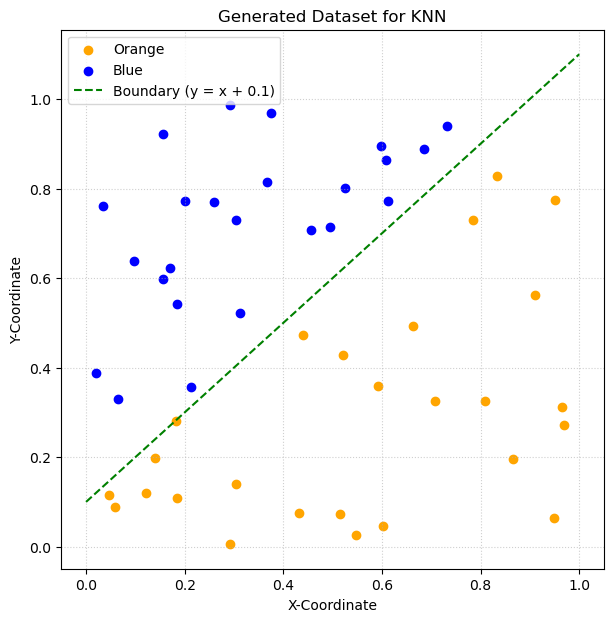


First 5 rows of the generated data:
          x         y   label
0  0.374540  0.969585    blue
1  0.950714  0.775133  orange
2  0.731994  0.939499    blue
3  0.598658  0.894827    blue
4  0.156019  0.597900    blue


In [4]:
#1. Generating Data

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set the number of points
n = 50
np.random.seed(42) # For reproducibility

# Generate coordinates (x, y) in the unit square [0, 1] x [0, 1]
x_coords = np.random.rand(n)
y_coords = np.random.rand(n)

# Define the boundary rule for labels (e.g., y > x + 0.1)
# Points above the line are 'blue', otherwise 'orange'
labels = np.where(y_coords > x_coords + 0.1, 'blue', 'orange')

# Store the data in a structured format (DataFrame)
data = pd.DataFrame({
    'x': x_coords,
    'y': y_coords,
    'label': labels
})

# Visualize the dataset
plt.figure(figsize=(7, 7))
orange_points = data[data['label'] == 'orange']
blue_points = data[data['label'] == 'blue']

plt.scatter(orange_points['x'], orange_points['y'], color='orange', label='Orange')
plt.scatter(blue_points['x'], blue_points['y'], color='blue', label='Blue')

# Add the boundary line used for clarity
x_line = np.linspace(0, 1, 100)
plt.plot(x_line, x_line + 0.1, color='green', linestyle='--', label='Boundary (y = x + 0.1)')

plt.title('Generated Dataset for KNN')
plt.xlabel('X-Coordinate')
plt.ylabel('Y-Coordinate')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print("\nFirst 5 rows of the generated data:")
print(data.head())

In [6]:
#2. The KNN Algorithm

# New point for classification (x0, y0)
x0 = np.array([0.3, 0.7])

# Extract training coordinates and labels
X_train = data[['x', 'y']].values 
y_train = data['label'].values    

# Calculate distances between (x0, y0) and all points in the dataset
distances = np.sqrt(np.sum((X_train - x0)**2, axis=1))

# Add distances to the DataFrame
data['distance'] = distances

# Sort the data by distance
sorted_data = data.sort_values(by='distance')

print("\nData sorted by distance to the new point (0.3, 0.7):")
print(sorted_data.head())

# Select K
K = 5 

# Identify the K nearest neighbors
k_nearest_neighbors = sorted_data.head(K)

print(f"\n{K} Nearest Neighbors:")
print(k_nearest_neighbors)

# Prediction based on the labels:
# Use majority voting: the predicted class is the label that occurs most frequently among the K nearest neighbors

# Count the labels
label_counts = k_nearest_neighbors['label'].value_counts()
predicted_class = label_counts.index[0]

print(f"\nLabel counts among the {K} neighbors:")
print(label_counts)
print(f"Predicted class for the point {x0} with K={K}: {predicted_class}")


Data sorted by distance to the new point (0.3, 0.7):
           x         y label  distance
36  0.304614  0.729606  blue  0.029964
44  0.258780  0.770967  blue  0.082070
26  0.199674  0.771270  blue  0.123064
23  0.366362  0.815461  blue  0.133174
31  0.170524  0.623298  blue  0.150490

5 Nearest Neighbors:
           x         y label  distance
36  0.304614  0.729606  blue  0.029964
44  0.258780  0.770967  blue  0.082070
26  0.199674  0.771270  blue  0.123064
23  0.366362  0.815461  blue  0.133174
31  0.170524  0.623298  blue  0.150490

Label counts among the 5 neighbors:
label
blue    5
Name: count, dtype: int64
Predicted class for the point [0.3 0.7] with K=5: blue


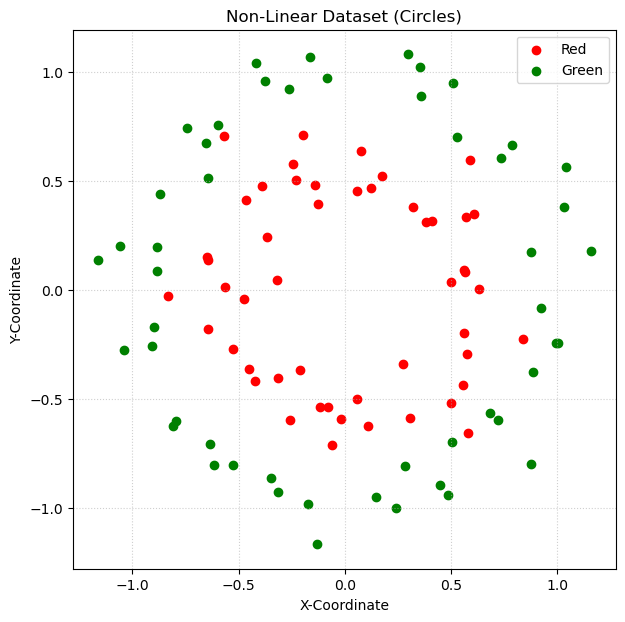


 Performance Evaluation (K=5, Euclidean Distance)
Accuracy: 0.8333
Precision: 0.6667
Recall: 1.0000
Confusion Matrix:
[[15  5]
 [ 0 10]]

 Performance Evaluation (K=5, Manhattan Distance)
Accuracy: 0.8667


In [8]:
#3. KNN for non-linear patterns

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Generate non-linear data ("Circles")
X_nonlinear, y_nonlinear = make_circles(n_samples=100, factor=.6, noise=.1, random_state=42)

# Create DataFrame
nonlinear_data = pd.DataFrame({
    'x': X_nonlinear[:, 0],
    'y': X_nonlinear[:, 1],
    'label': np.where(y_nonlinear == 1, 'red', 'green')
})

# Visualize the non-linear dataset
plt.figure(figsize=(7, 7))
red_points = nonlinear_data[nonlinear_data['label'] == 'red']
green_points = nonlinear_data[nonlinear_data['label'] == 'green']

plt.scatter(red_points['x'], red_points['y'], color='red', label='Red')
plt.scatter(green_points['x'], green_points['y'], color='green', label='Green')

plt.title('Non-Linear Dataset (Circles)')
plt.xlabel('X-Coordinate')
plt.ylabel('Y-Coordinate')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Split the data into training and testing sets (70% train, 30% test)
X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(
    X_nonlinear, y_nonlinear, test_size=0.3, random_state=42
)

# Test and Evaluate using Euclidean Distance
# Create and train the KNN model with K=5
knn_euclidean = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_euclidean.fit(X_train_nl, y_train_nl)

# Generate predictions on the test set
y_pred_euclidean = knn_euclidean.predict(X_test_nl)

# Measure performance
accuracy_e = accuracy_score(y_test_nl, y_pred_euclidean)
precision_e = precision_score(y_test_nl, y_pred_euclidean, average='binary') 
recall_e = recall_score(y_test_nl, y_pred_euclidean, average='binary')                    

print(f"\n Performance Evaluation (K=5, Euclidean Distance)")
print(f"Accuracy: {accuracy_e:.4f}")
print(f"Precision: {precision_e:.4f}")
print(f"Recall: {recall_e:.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test_nl, y_pred_euclidean)}")

# Test and Evaluate using Manhattan Distance
# Create and train the KNN model using Manhattan distance (metric='manhattan')
knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_manhattan.fit(X_train_nl, y_train_nl)

# Generate predictions
y_pred_manhattan = knn_manhattan.predict(X_test_nl)

# Measure performance
accuracy_m = accuracy_score(y_test_nl, y_pred_manhattan)

print(f"\n Performance Evaluation (K=5, Manhattan Distance)")
print(f"Accuracy: {accuracy_m:.4f}")

---
---

# **Support Vector Machine**

A dataset contains two classes: Class A ($y=+1$ ) and Class B ($y=-1$).

You are given six labeled data points in a 2D space:

| Point $ x_i $     | Label $ y_i $  |
|-------------------|---------------|
| $ x_1 = [2, 3] $   | $ +1 $         |
| $ x_2 = [1, 2] $   | $ +1 $         |
| $ x_3 = [3, 1] $   | $ +1 $         |
| $ x_4 = [1, 0] $   | $ -1 $         |
| $ x_5 = [2, -1] $  | $ -1 $         |
| $ x_6 = [0, 0] $   | $ -1 $         |

---

### **1. Sketch & intuition**
- **1.1:** Plot the six points on a 2D graph with $ x_1 $ -$ x_2 $  axes. Do the two classes form distinct clusters ?
- **1.2:** What does it mean for the two classes to be linearly separable ? What would this imply about the complexity of the classification problem ?
- **1.3:** Are the two classes linearly separable ? If yes, arbitrarily sketch a decision boundary (no need to optimize it yet).
- **1.4:** What is the margin in the context of a decision boundary?
- **1.5:** Why would we like to maximize the margin ? What might happen if the margin is very small ? (think about new observations and future predictions)

---

### **2. Decision Boundary for Hard-Margin**
The decision boundary for an SVM is represented as:

$$
x^T \beta + \beta_0 = 0, \quad \text{where } \beta = [\beta_1, \beta_2]^T \text{are some weights}, \text{ and } \beta_0 \text{ is the intercept.}
$$

- **2.1:** Write down the margin constraints:

$$
y_i (\beta^T x_i + \beta_0) \geq 1
$$

For each observation ($ x_1, x_2, ..., x_6 $ ), substitute $x_i$  and $y_i$  into the inequality.

- **2.2** What does the margin constraint enforce for a correctly classified point ? Explain what this constraint means for points with $y_i=+1$ and $y_i=−1$.

- **2.3** Lets say our solver choose random initial values to specify a decision boundary:
    - $\beta = [1, -1]^T$ 
    - $\beta_0 = 0$

Verify step by step, whether the margin constraint is satisfied for each observation ($x_1, x_2, \ldots, x_6$ ) given their respective labels ($y_1, y_2, \ldots, y_6$ ). Sketch the decision line.

- **2.4** At the second iteration, our solver updates the parameters : $\beta = [2, 2]^T$ & $\beta_0 = -4$. Check again the conditions for each observations and draw the line. Does the margin look to be maximized here ? Compute its lenght :  $$M = \frac{1}{||\beta||}$$,
where $ ||\beta|| = \sqrt{\beta_1^2 + \beta_2^2} $ .



- **2.5: Using sklearn (https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html), write a code to find the decision line that maximize the margin. What are the estimated parameters ? Plot the line.**
    (Hint : use the linear kernel parameter)



### 1. Sketch & Intuition

#### 1.1. Plot the six points on a 2D graph. Do the two classes form distinct clusters?

Yes, the two classes form **distinct clusters**. Class A ($y=+1$) is grouped in the upper-right area, and Class B ($y=-1$) is grouped in the lower-left area. They are clearly separated.

| Point $x_i$ | $x_1$ | $x_2$ | Label $y_i$ |
| :---: | :---: | :---: | :---: |
| $x_1$ | 2 | 3 | $+1$ |
| $x_2$ | 1 | 2 | $+1$ |
| $x_3$ | 3 | 1 | $+1$ |
| $x_4$ | 1 | 0 | $-1$ |
| $x_5$ | 2 | -1 | $-1$ |
| $x_6$ | 0 | 0 | $-1$ |

#### 1.2. What does it mean for the two classes to be linearly separable?

* **Linearly Separable:** A straight line (hyperplane) can perfectly separate all data points of one class from all points of the other class.
* **Implication:** The classification problem is **straightforward**. We can use a **linear model** (Hard-Margin SVM).

#### 1.3. Are the two classes linearly separable? 

**Yes**, they are linearly separable.

#### 1.4. What is the margin in the context of a decision boundary?

The **margin** is the **maximum two-sided distance** between the separating hyperplane and the **closest data points** (Support Vectors).

#### 1.5. Why would we like to maximize the margin?

* **Maximizing the Margin** leads to the **most robust** and **best generalizing** decision boundary, creating a larger "buffer zone" for new observations.
* **Small Margin** makes the model **sensitive to noise** (overfitting).

### 2. Decision Boundary for Hard-Margin

The decision boundary is $x^T \beta + \beta_0 = 0$.

#### 2.1. Write down the margin constraints: $y_i (\beta^T x_i + \beta_0) \geq 1$

The six constraints are ($\beta^T x_i = \beta_1 x_{i1} + \beta_2 x_{i2}$):

1.  $x_1=[2, 3], y_1=+1 \implies \mathbf{2\beta_1 + 3\beta_2 + \beta_0 \geq 1}$
2.  $x_2=[1, 2], y_2=+1 \implies \mathbf{1\beta_1 + 2\beta_2 + \beta_0 \geq 1}$
3.  $x_3=[3, 1], y_3=+1 \implies \mathbf{3\beta_1 + 1\beta_2 + \beta_0 \geq 1}$
4.  $x_4=[1, 0], y_4=-1 \implies \mathbf{-\beta_1 - \beta_0 \geq 1}$
5.  $x_5=[2, -1], y_5=-1 \implies \mathbf{-2\beta_1 + \beta_2 - \beta_0 \geq 1}$
6.  $x_6=[0, 0], y_6=-1 \implies \mathbf{-\beta_0 \geq 1}$

#### 2.2. What does the margin constraint enforce?

The constraint ensures that every point is not only **correctly classified** but also lies **on or outside** the margin boundaries (at least a distance of $1/||\beta||$ from the decision boundary).

#### 2.3. Verification for Trial 1: $\beta = [1, -1]^T$ & $\beta_0 = 0$ (Boundary: $x_1 - x_2 = 0$)

The constraints are **NOT satisfied** (e.g., $x_1$ gives $y_1(\beta^T x_1 + \beta_0) = -1$, but we need $\geq 1$).

#### 2.4. Verification for Trial 2: $\beta = [2, 2]^T$ & $\beta_0 = -4$ (Boundary: $x_1 + x_2 = 2$)

**So,** All margin constraints **are satisfied**.

**Margin Length $M$:**
$$
M = \frac{2}{||\beta||} = \frac{2}{\sqrt{2^2 + 2^2}} = \frac{2}{\sqrt{8}} \approx 0.707
$$
The margin is satisfied, but it is **not maximized**.

In [16]:
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm

X = np.array([
    [2, 3], [1, 2], [3, 1], 
    [1, 0], [2, -1], [0, 0]  
])
y = np.array([1, 1, 1, -1, -1, -1])

# Hard-Margin SVM (Using C=1e10)
clf = SVC(kernel='linear', C=1e10) 
clf.fit(X, y)

# Parameters
beta = clf.coef_[0]
beta_0 = clf.intercept_[0]
optimal_norm = norm(beta)
M_optimal = 2 / optimal_norm

print(f"Sklearn Estimated Parameters (Max Margin)")
print(f"Beta vector (weights) [β₁ , β₂]: {beta}")
print(f"Intercept (β₀): {beta_0:.4f}")
print(f"Optimal Decision Line: {beta[0]:.4f}x₁ + {beta[1]:.4f}x₂ + {beta_0:.4f} = 0")
print(f"Simplified Line: x₁ + x₂ = 3")
print(f"Max Margin Length (2/||β||): {M_optimal:.4f}")
print(f"Support Vectors:\n{clf.support_vectors_}")

Sklearn Estimated Parameters (Max Margin)
Beta vector (weights) [β₁ , β₂]: [0.49984 0.99968]
Intercept (β₀): -1.4994
Optimal Decision Line: 0.4998x₁ + 0.9997x₂ + -1.4994 = 0
Simplified Line: x₁ + x₂ = 3
Max Margin Length (2/||β||): 1.7894
Support Vectors:
[[1. 0.]
 [1. 2.]
 [3. 1.]]


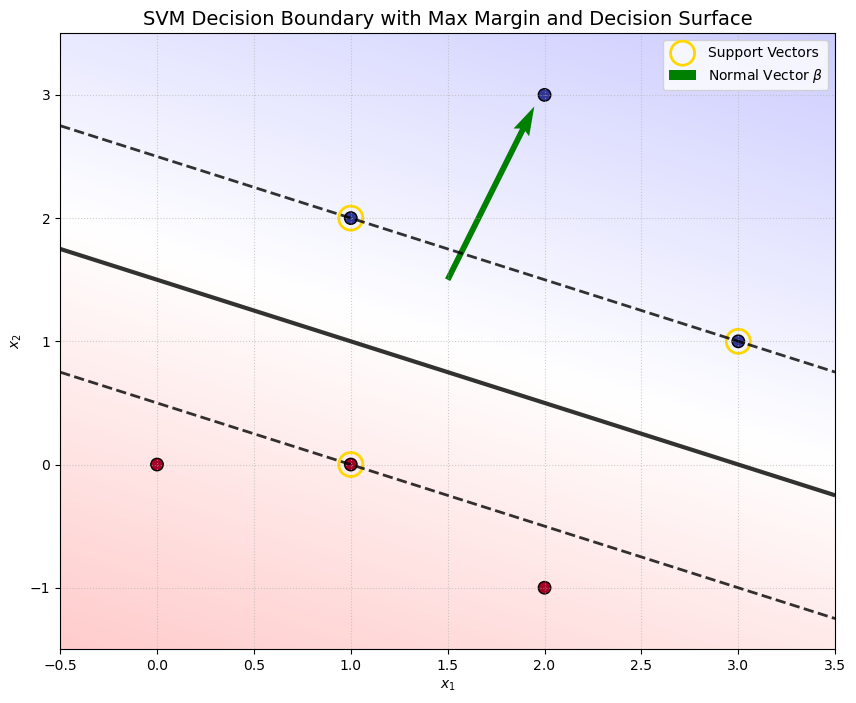

In [17]:
#Enhanced Visualization

plt.figure(figsize=(10, 8))

# 2.1. Define the plot boundaries and meshgrid
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), 
                     np.linspace(y_min, y_max, 500))

# 2.2. Calculate the decision function Z for the background gradient
# Z will represent the distance from the decision boundary for every point
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Create a custom colormap for the background
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'RedBlue', ['#FFCCCC', '#FFFFFF', '#CCCCFF'], 256
)

# Plot the background gradient (Decision Surface)
plt.imshow(Z, interpolation='nearest',
           extent=(xx.min(), xx.max(), yy.min(), yy.max()), aspect='auto',
           origin='lower', cmap=cmap)


# 2.3. Plot the Hyperplane (Decision Boundary) and Margin Lines
# Use contour lines for a clean look

# levels=[-1, 0, 1] plot the two margin lines and the decision boundary
# colors=['red', 'black', 'blue'] sets distinct colors
plt.contour(xx, yy, Z, colors=['k', 'k', 'k'], levels=[-1, 0, 1], alpha=0.8,
            linestyles=['--', '-', '--'], linewidths=[2, 3, 2])

# 2.4. Plot the Data Points and Support Vectors
# Data points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, s=80, edgecolors='k', marker='o')

# Support Vectors (ring around the data points)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=300, 
            facecolors='none', edgecolors='gold', linewidth=2, marker='o', label='Support Vectors')


# 2.5. Visualize the Normal Vector (β) 
# The normal vector starts at the decision boundary (x1+x2=3) and points towards +1 class.
# Let's anchor it at a point on the line, e.g., (1.5, 1.5).
anchor_x = 1.5
anchor_y = 1.5

plt.quiver(anchor_x, anchor_y, beta[0], beta[1], 
           scale=optimal_norm * 4, color='green', linewidth=1, 
           label='Normal Vector $\\beta$')

# 2.6. Final Touches
plt.title('SVM Decision Boundary with Max Margin and Decision Surface', fontsize=14)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#


---

### **3. Slack Variables for a Soft-Margin**
In real-world datasets, perfect separation might not be possible as the data might be mixed. 

Lets add two new observations : 
- $ x_7 = [1, 3] $  with $y_7 = +1 $
- $ x_8 = [3, -2] $  with $y_8 = -1 $


Slack variables ($ \xi_i $ ) can be added to relax the SVM constraint for incorrectly classified or margin-violating points:

$$

y_i (\beta^T x_i + \beta_0) \geq 1 - \xi_i, \quad \xi_i \geq 0

$$


They are computed by the Hinge Loss function:

$$
\xi_i = \max(0, 1 - y_i (\beta^T x_i + \beta_0))
$$

- **3.1: Check for each observation if the point violates the soft-margin constraint. Compute the slack variable $ \xi_i $  for each point.**


- **3.2: What is the slack variable when the observation is well classified ?**

- **3.3: Identify the points that violate the margin.**

- **3.3: Compute the total violation:**

$$

\text{Total Slack:} \quad \sum_{i=1}^n \xi_i.

$$

---

### **4. Adding Slack Variables to the Objective Function**

The objective function that we used for the hard margin can be modified to include the penalty term for the slack variables. By doing so, our final problem is :

$$
 \text{minimize} \quad \frac{1}{2} \|\beta\|^2 + C \sum_{i=1}^{n} \xi_i 
$$

subject to :

$$
 y_i (\beta \cdot x_i + b) \geq 1 - \xi_i \quad \forall i 
$$



$$
 \xi_i \geq 0 \quad \forall i 
$$

Where, 

1. $ \frac{1}{2} \|\beta\|^2 $ encourages a large margin by minimizing the norm of the weight vector.
2. $C \sum_{i=1}^{n} \xi_i$ penalizes the slack variables. $C$  is a regularization parameter that controls the trade-off between maximizing the margin and minimizing the classification error.
3. $ y_i (\beta \cdot x_i + b) \geq 1 - \xi_i $ : This constraint allows for some points to be within the margin or misclassified, thanks to the slack variable.
4. $ \xi_i \geq 0 $ : Ensures that slack variables are non-negative.

By adding slack variables to the objective function, the soft margin SVM can handle non-separable data more effectively, balancing the need for a large margin with the practical reality of misclassifications.

- **4. How does increasing or decreasing C affect the trade-off between maximizing the margin and minimizing classification errors ?**

---


### 3. Slack Variables for a Soft-Margin ($\xi_i$)

We use the optimal Hard-Margin parameters found in the previous step:
$$\beta = [0.5, 0.5]^T \quad \text{and} \quad \beta_0 = -1.5$$

We calculate the Functional Margin $f_i = y_i (\beta^T x_i + \beta_0)$ and the Slack Variable $\xi_i = \max(0, 1 - f_i)$ for all 8 points.

#### 3.1: Check and Compute Slack Variable $\xi_i$

| $i$ | $x_i=[x_{i1}, x_{i2}]$ | $y_i$ | $\beta^T x_i + \beta_0$ | $f_i = y_i(\dots)$ | $\xi_i = \max(0, 1 - f_i)$ | **Violation Type** |
| :--: | :---: | :---: | :---: | :---: | :---: | :---: |
| 1 | [2, 3] | +1 | $1.0$ | $1.0$ | **0** | On Margin |
| **2** | [1, 2] | +1 | $0.0$ | $0.0$ | **1.0** | **On Hyperplane** |
| **3** | [3, 1] | +1 | $0.5$ | $0.5$ | **0.5** | **Inside Margin** |
| 4 | [1, 0] | -1 | $-1.0$ | $1.0$ | **0** | On Margin |
| 5 | [2, -1] | -1 | $-1.0$ | $1.0$ | **0** | On Margin |
| 6 | [0, 0] | -1 | $-1.5$ | $1.5$ | **0** | Outside Margin |
| **7** | **[1, 3]** | **+1** | $0.5$ | **0.5** | **0.5** | **Inside Margin** |
| 8 | **[3, -2]** | **-1** | $-1.0$ | $1.0$ | **0** | On Margin |

#### 3.2: What is the slack variable when the observation is well classified?

* If the point is **outside the margin** or **on the margin** ($f_i \geq 1$), then $\mathbf{\xi_i = 0}$.
* If the point is **inside the margin** ($0 < f_i < 1$), the point is still correctly classified, but $\mathbf{\xi_i = 1 - f_i > 0}$.

#### 3.3: Identify the points that violate the margin.

Points that violate the **Hard-Margin constraint** (where $\xi_i > 0$):
* $x_2$ ($\xi_2 = 1.0$)
* $x_3$ ($\xi_3 = 0.5$)
* $x_7$ ($\xi_7 = 0.5$)

#### 3.4: Compute the total violation: $\sum_{i=1}^n \xi_i$

$$\text{Total Slack} = 0 + 1.0 + 0.5 + 0 + 0 + 0 + 0.5 + 0 = \mathbf{2.0}$$

### 4. Adding Slack Variables to the Objective Function

The objective function for Soft-Margin SVM is:
$$
\text{minimize} \quad \frac{1}{2} \|\beta\|^2 + C \sum_{i=1}^{n} \xi_i
$$

#### 4. How does increasing or decreasing C affect the trade-off?

The regularization parameter $\mathbf{C}$ controls the trade-off between maximizing the margin (minimizing $\frac{1}{2} \|\beta\|^2$) and minimizing classification error/margin violations (minimizing $\sum \xi_i$). 

| Parameter C | Effect on Margin Term ($\frac{1}{2} \|\beta\|^2$) | Effect on Penalty Term ($C \sum \xi_i$) | Resulting Model Trade-off |
| :---: | :---: | :---: | :---: |
| **$C \uparrow$ (Large)** | Term's influence decreases. | Penalty for slack **increases**. | **Harder Margin:** Model prioritizes minimizing errors ($\sum \xi_i$ is small). Leads to a **narrower margin** and higher risk of **overfitting**. |
| **$C \downarrow$ (Small)** | Term's influence increases. | Penalty for slack **decreases**. | **Softer Margin:** Model prioritizes a **wider margin** (allows larger $\sum \xi_i$). Leads to a simpler, more robust, and better **generalizing** model (lower risk of overfitting). |